In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('global_cancer_patients_2015_2024.csv')
df.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,50000.0,54.421540,20.224451,20.00,37.000,54.00,72.00,89.00
Year,50000.0,2019.480520,2.871485,2015.00,2017.000,2019.00,2022.00,2024.00
Genetic_Risk,50000.0,5.001698,2.885773,0.00,2.500,5.00,7.50,10.00
Air_Pollution,50000.0,5.010126,2.888399,0.00,2.500,5.00,7.50,10.00
Alcohol_Use,50000.0,5.010880,2.888769,0.00,2.500,5.00,7.50,10.00
Smoking,50000.0,4.989826,2.881579,0.00,2.500,5.00,7.50,10.00
Obesity_Level,50000.0,4.991176,2.894504,0.00,2.500,5.00,7.50,10.00
Treatment_Cost_USD,50000.0,52467.298239,27363.229379,5000.05,28686.225,52474.31,76232.72,99999.84
Survival_Years,50000.0,5.006462,2.883335,0.00,2.500,5.00,7.50,10.00
Target_Severity_Score,50000.0,4.951207,1.199677,0.90,4.120,4.95,5.78,9.16


In [5]:
df.describe(include='object').T

,count,unique,top,freq
Patient_ID,50000,50000,PT0049983,1
Gender,50000,3,Male,16796
Country_Region,50000,10,Australia,5092
Cancer_Type,50000,8,Colon,6376
Cancer_Stage,50000,5,Stage II,10124


In [6]:
df.drop(['Patient_ID'], axis=1, inplace=True)

c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(

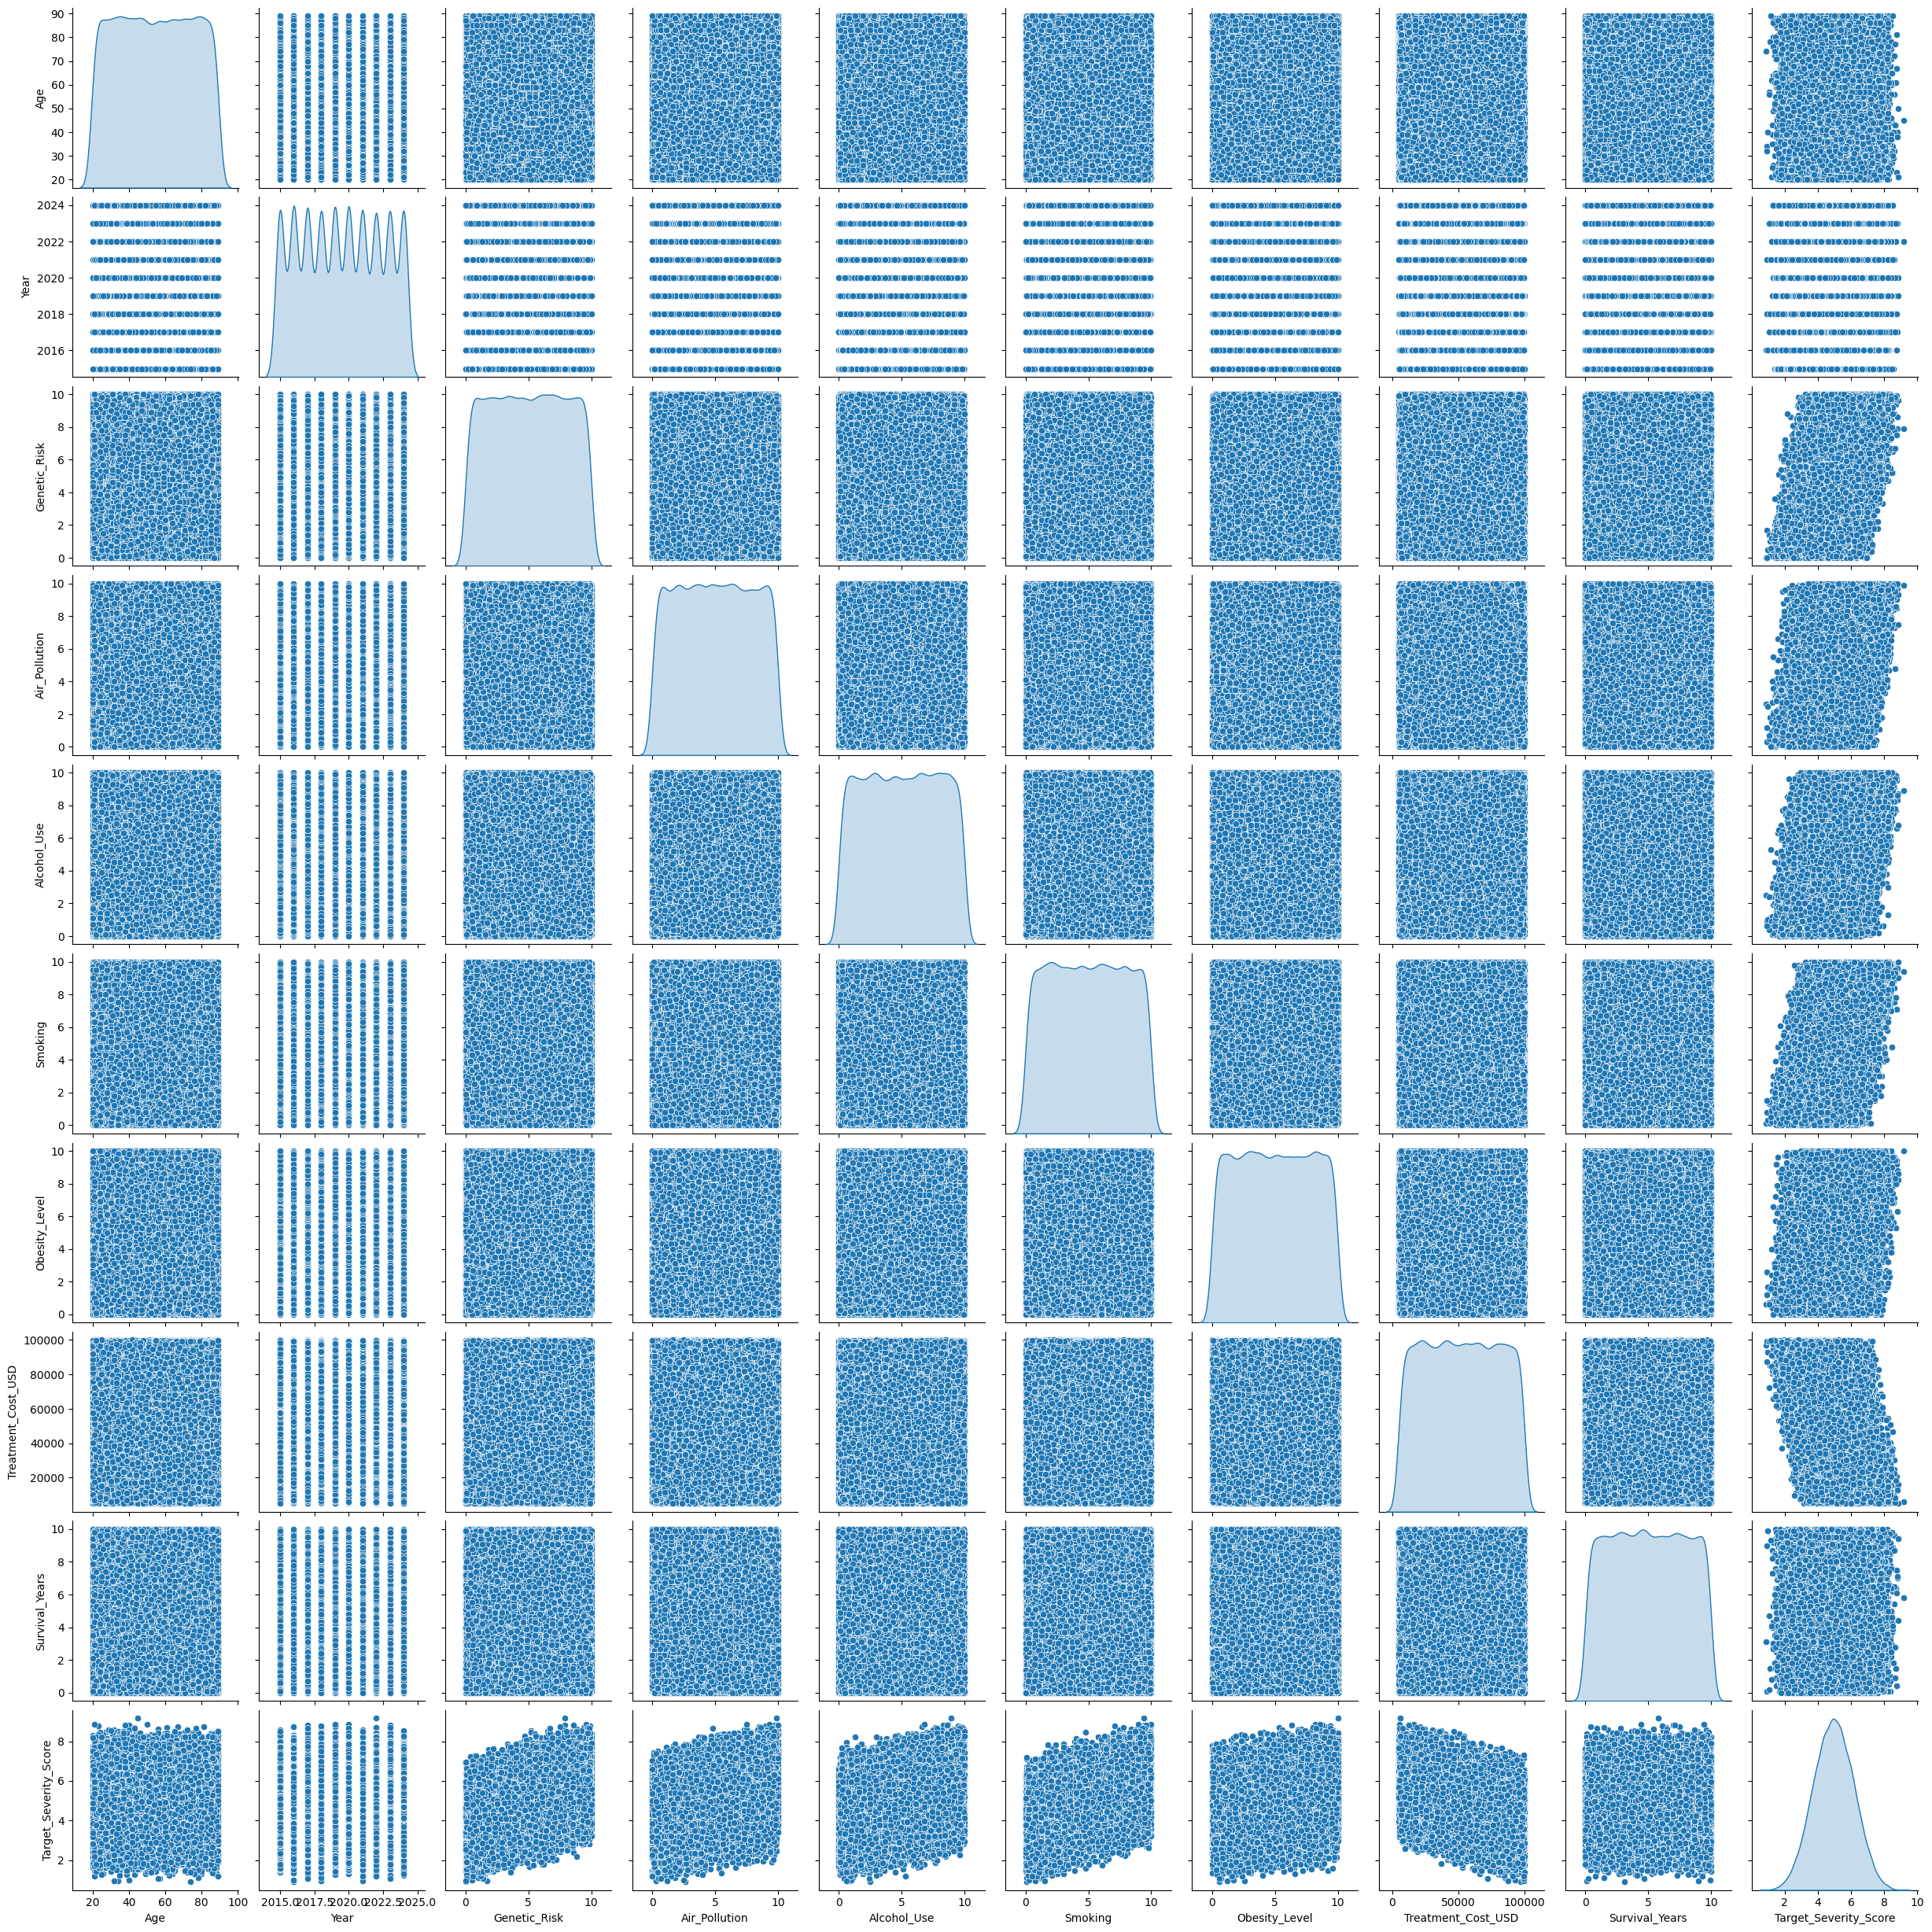

In [7]:
numeric_features = df.select_dtypes(include=[np.int64, np.float64]).columns.tolist()
# apply pair plot on numerical features
sns.pairplot(df[numeric_features], diag_kind='kde', markers='o', palette='Set1')

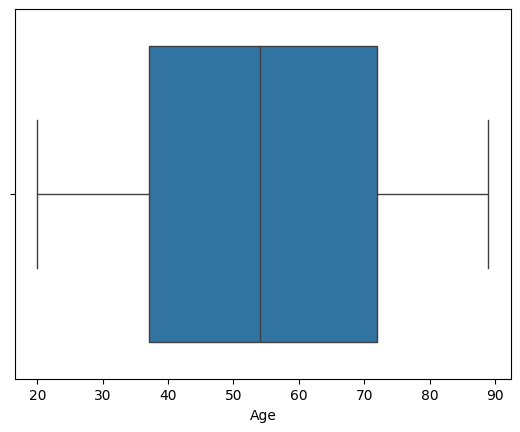

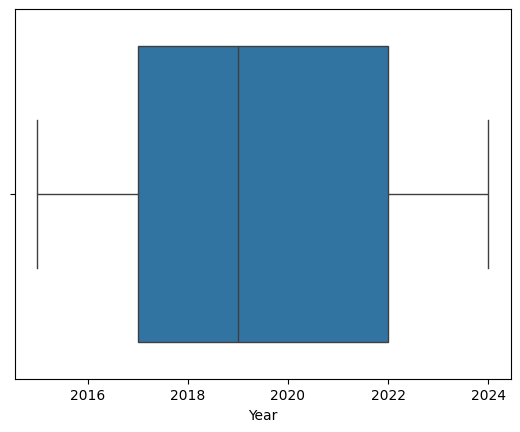

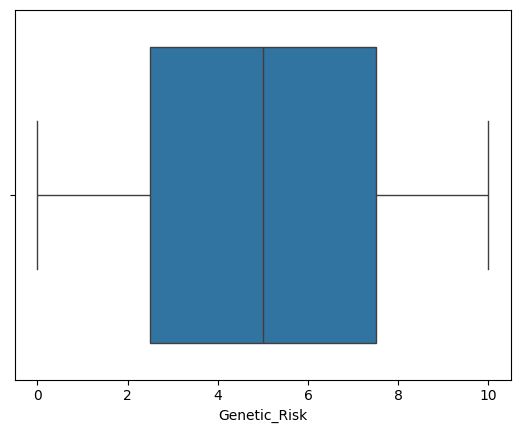

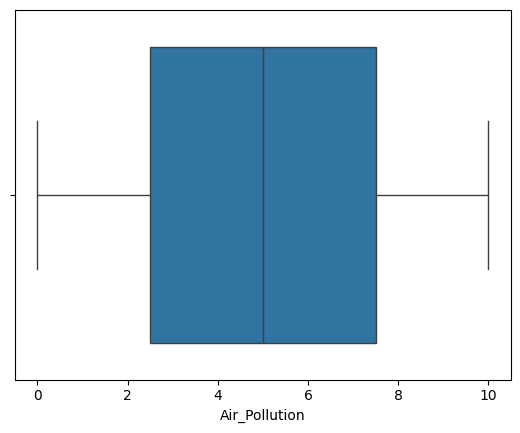

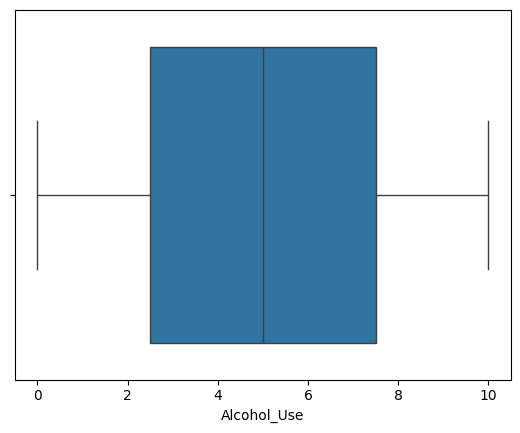

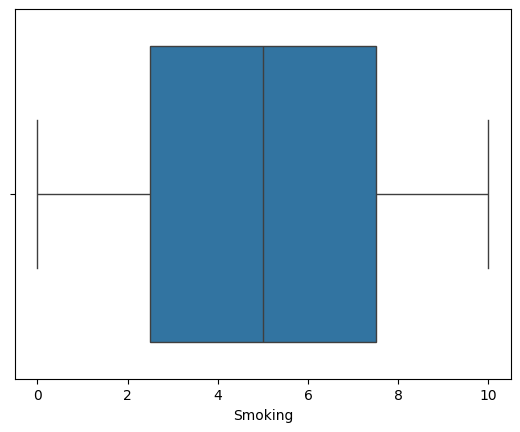

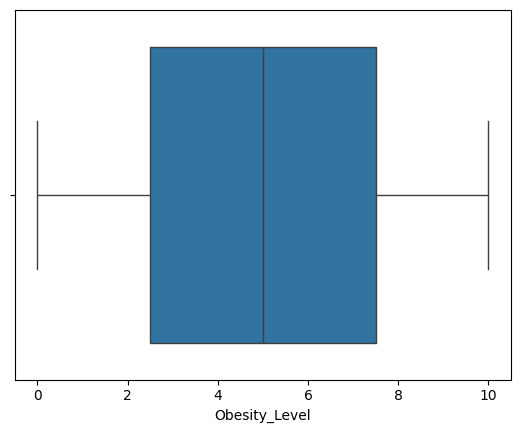

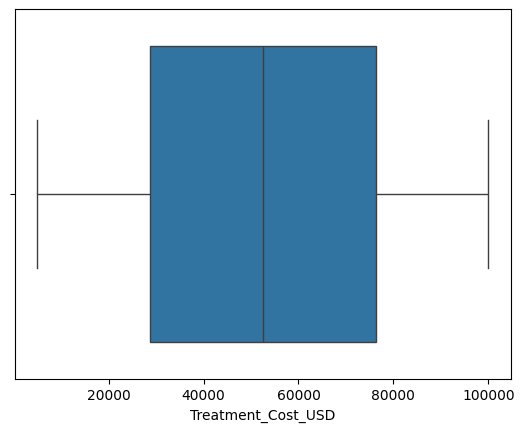

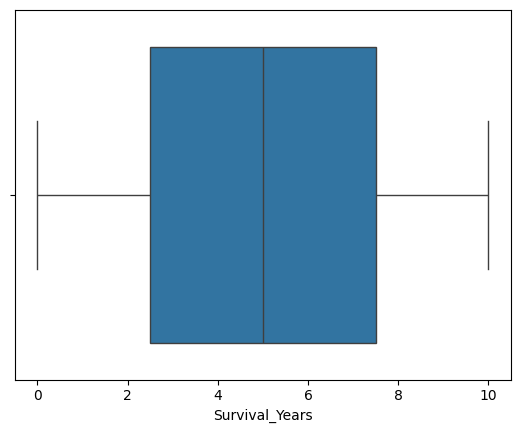

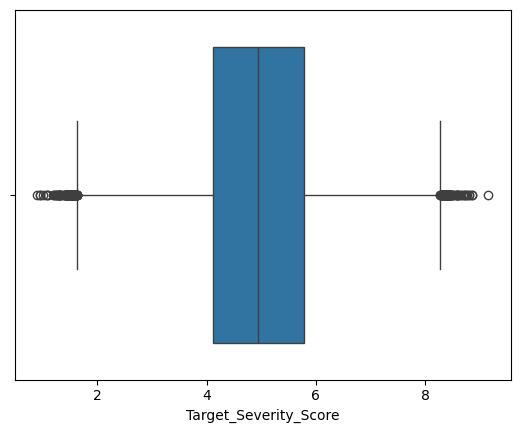

In [8]:
for col in numeric_features:
 plt.figure()
 sns.boxplot(data=df,x= col)

In [9]:

categorical_features = df.select_dtypes(include=[object]).columns.tolist()
categorical_features

['Gender', 'Country_Region', 'Cancer_Type', 'Cancer_Stage']

In [10]:
df.isnull().sum()

Age                      0
Gender                   0
Country_Region           0
Year                     0
Genetic_Risk             0
Air_Pollution            0
Alcohol_Use              0
Smoking                  0
Obesity_Level            0
Cancer_Type              0
Cancer_Stage             0
Treatment_Cost_USD       0
Survival_Years           0
Target_Severity_Score    0
dtype: int64

In [11]:
def detect_outliers_iqr(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return outliers

# Check outliers in each numerical column
for col in numeric_features:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
Year: 0 outliers
Genetic_Risk: 0 outliers
Air_Pollution: 0 outliers
Alcohol_Use: 0 outliers
Smoking: 0 outliers
Obesity_Level: 0 outliers
Treatment_Cost_USD: 0 outliers
Survival_Years: 0 outliers
Target_Severity_Score: 151 outliers


In [12]:
outliers_cols = ['Target_Severity_Score']
for col in outliers_cols:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")

Target_Severity_Score: 151 outliers


In [13]:
from sklearn.preprocessing import RobustScaler

# Apply robust scaling on cols that have outliers
for col in outliers_cols:
    scaler = RobustScaler()
    df[col] = scaler.fit_transform(df[[col]])   

In [14]:
categorical_features = df.select_dtypes(include=[object]).columns.tolist()
for col in categorical_features:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts())
    print("-----")

Gender: 3 unique values
Gender
Male      16796
Female    16709
Other     16495
Name: count, dtype: int64
-----
Country_Region: 10 unique values
Country_Region
Australia    5092
UK           5060
USA          5060
India        5040
Germany      5024
Russia       5017
Brazil       5004
Pakistan     4926
China        4913
Canada       4864
Name: count, dtype: int64
-----
Cancer_Type: 8 unique values
Cancer_Type
Colon       6376
Prostate    6308
Leukemia    6266
Liver       6249
Skin        6231
Cervical    6222
Breast      6189
Lung        6159
Name: count, dtype: int64
-----
Cancer_Stage: 5 unique values
Cancer_Stage
Stage II     10124
Stage I      10046
Stage III    10008
Stage IV      9933
Stage 0       9889
Name: count, dtype: int64
-----


In [15]:
data=pd.concat([df[numeric_features],pd.get_dummies(df[categorical_features])],axis=1)

In [16]:
data.head()

,Age,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Treatment_Cost_USD,Survival_Years,Target_Severity_Score,...,Cancer_Type_Leukemia,Cancer_Type_Liver,Cancer_Type_Lung,Cancer_Type_Prostate,Cancer_Type_Skin,Cancer_Stage_Stage 0,Cancer_Stage_Stage I,Cancer_Stage_Stage II,Cancer_Stage_Stage III,Cancer_Stage_Stage IV
0,71,2021,6.4,2.8,9.5,0.9,8.7,62913.44,5.9,-0.018072,...,False,False,True,False,False,False,False,False,True,False
1,34,2021,1.3,4.5,3.7,3.9,6.3,12573.41,4.7,-0.180723,...,True,False,False,False,False,True,False,False,False,False
2,80,2023,7.4,7.9,2.4,4.7,0.1,6984.33,7.1,0.536145,...,False,False,False,False,False,False,False,True,False,False
3,40,2015,1.7,2.9,4.8,3.5,2.7,67446.25,1.6,-1.102410,...,False,False,False,False,False,False,True,False,False,False
4,43,2017,5.1,2.8,2.3,6.7,0.5,77977.12,2.9,-0.801205,...,False,False,False,False,True,False,False,False,True,False


In [18]:
data.info()

 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       50000 non-null  int64  
 1   Year                      50000 non-null  int64  
 2   Genetic_Risk              50000 non-null  float64
 3   Air_Pollution             50000 non-null  float64
 4   Alcohol_Use               50000 non-null  float64
 5   Smoking                   50000 non-null  float64
 6   Obesity_Level             50000 non-null  float64
 7   Treatment_Cost_USD        50000 non-null  float64
 8   Survival_Years            50000 non-null  float64
 9   Target_Severity_Score     50000 non-null  float64
 10  Gender_Female             50000 non-null  bool   
 11  Gender_Male               50000 non-null  bool   
 12  Gender_Other              50000 non-null  bool   
 13  Country_Region_Australia  50000 non-null  bool   
 14  Countr

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score
import mlflow
import joblib


In [ ]:

x=data.drop(columns=['Target_Severity_Score'])
y=data['Target_Severity_Score']

In [21]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,shuffle=True,random_state=42)

In [22]:
print(x.shape, x_train.shape, x_test.shape)

(50000, 35) (40000, 35) (10000, 35)


In [23]:
scaler = StandardScaler()

# standardizing the features
x_train_Scaled = scaler.fit_transform(x_train)
x_test_Scaled  = scaler.transform(x_test)

In [24]:
model_reg = LinearRegression()

In [25]:
with mlflow.start_run():
    model_reg.fit(x_train_Scaled, y_train)

In [26]:
y_pred = model_reg.predict(x_test_Scaled)

In [27]:
cof = model_reg.coef_
intarap = model_reg.intercept_
print( 'coff is a : ' , cof)
print('-------------')
print( ' intercept : ' , intarap)

coff is a :  [-2.73087637e-06 -5.50026754e-06  3.47519544e-01  2.60508312e-01
  2.61631645e-01  3.47246927e-01  1.74327946e-01 -3.28931199e-01
 -8.04063893e-07  1.15890119e-06 -4.52839799e-07 -7.08772597e-07
  4.05247838e-06 -1.82590996e-05  6.88712579e-06  9.45706331e-06
 -6.37804936e-06 -1.04610490e-06  1.27296372e-05 -6.31373083e-06
 -3.73626988e-06  2.92580278e-06  9.99093751e-06 -4.95952272e-07
  1.01135368e-06  1.98687126e-06  1.42173991e-05 -2.60966010e-06
 -7.88085726e-07 -2.32691282e-05  2.70834744e-06 -1.99944359e-06
  7.51234468e-06 -4.42806906e-06 -3.83302862e-06]
-------------
 intercept :  0.002255421686746788


In [28]:
acc = model_reg.score(x_test, y_pred )
score_1 = r2_score(y_test, y_pred)
score_2 = mean_absolute_error(y_test, y_pred)
score_3 = mean_squared_error(y_test, y_pred)

print('R2 Score : ', score_1)
print('Mean Absolute Error : ', score_2)
print('Mean Squared Error : ', score_3)
print('  Error : ', acc )
mlflow.log_param("model_type", "LinearRegression")

mlflow.log_metric("accuracy", acc)
mlflow.log_metric("mse", score_3)

R2 Score :  0.9999941377631747
Mean Absolute Error :  0.001503623307911245
Mean Squared Error :  3.0227397201996588e-06
  Error :  -740331250.8232669


c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


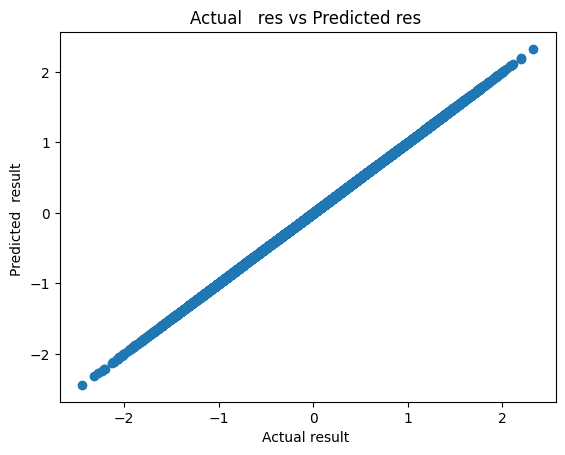

In [29]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual result ")
plt.ylabel("Predicted  result ")
plt.title("Actual   res vs Predicted res ")
plt.show()

In [30]:
# تسجيل النموذج في MLflow
mlflow.sklearn.log_model(model_reg, artifact_path="model", registered_model_name="Regression_cancer_model")
print(f"✅ Model trained and logged! MSE: {score_3:.4f}")

2025/10/12 21:56:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2025/10/12 21:57:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Successfully registered model 'Regression_cancer_model'.


✅ Model trained and logged! MSE: 0.0000


Created version '1' of model 'Regression_cancer_model'.


In [31]:
# Save model locally with joblib

joblib.dump(model_reg, "regression_cancer.joblib")

print("✅ Model saved locally as regression_cancer.joblib")


✅ Model saved locally as regression_cancer.joblib


In [35]:
joblib.dump(scaler, "scaler.pkl")
print("✅ scaler.pkl saved successfully!")

✅ scaler.pkl saved successfully!


In [34]:
model_columns = x_train.columns.tolist()
joblib.dump(model_columns, "model_columns.pkl")
print("✅ model_columns.pkl saved successfully!")


✅ model_columns.pkl saved successfully!
